# Problem Statement 3: Handling OOV Words in HMMs
## Title: Unknown Word Handling and Smoothing in POS Tagging

---

### Group Details
| Field | Details |
|---|---|
| **Group Number** | 125 |
| **Domain** | Domain 2: Gaming Forums / Discord Transcripts |
| **Dataset** | Universal Dependencies English Web Treebank (EWT) |
| **Dataset Source** | https://raw.githubusercontent.com/UniversalDependencies/UD_English-EWT/master/en_ewt-ud-train.conllu |

| Member Name  | BITS ID     | Contribution (%) |
|--------------|-------------|---|
| Hemesh Joshi | 2025AA05046 | 25% |
| Member 2     | 2023XXXX002 | 25% |
| Member 3     | 2023XXXX003 | 25% |
| Member 4     | 2023XXXX004 | 25% |

> **Note:** Update member names, BITS IDs, and contribution percentages before submission.


## Setup & Imports

In [1]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'nltk', 'requests',
                'matplotlib', 'seaborn', 'pandas', 'numpy', 'tabulate'],
               capture_output=True)

import re, math, random, requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict, Counter
from tabulate import tabulate

print('All libraries imported successfully.')

All libraries imported successfully.


---
## Task 1 — Load Dataset, Parse 10,000 Sentences & Frequency Distribution (1 Mark)

We use the **Universal Dependencies English Web Treebank (EWT)** which contains weblogs, newsgroups,
emails, reviews and Yahoo! Answers — text that closely mirrors gaming-forum and Discord-style colloquial language.
It is publicly available and freely downloadable.

**Source:** https://raw.githubusercontent.com/UniversalDependencies/UD_English-EWT/master/en_ewt-ud-train.conllu


In [2]:
CONLLU_URL = (
    'https://raw.githubusercontent.com/UniversalDependencies/'
    'UD_English-EWT/master/en_ewt-ud-train.conllu'
)
print('Downloading dataset ...')
resp = requests.get(CONLLU_URL, timeout=60)
resp.raise_for_status()
raw_text = resp.text
print(f'Downloaded {len(raw_text):,} characters')

Downloaded 15,033,571 characters


In [3]:
def parse_conllu(text, max_sentences=10_000):
    """Parse CoNLL-U format into list of [(word, upos)] sentence lists."""
    sentences, current = [], []
    for line in text.splitlines():
        if line.startswith('#') or line.strip() == '':
            if current:
                sentences.append(current)
                current = []
                if len(sentences) >= max_sentences:
                    break
        else:
            parts = line.split('\t')
            if len(parts) >= 4 and parts[0].isdigit():
                current.append((parts[1], parts[3]))
    if current and len(sentences) < max_sentences:
        sentences.append(current)
    return sentences

sentences = parse_conllu(raw_text, max_sentences=10_000)
print(f'Total sentences parsed : {len(sentences):,}')
print(f'Total tokens           : {sum(len(s) for s in sentences):,}')
print('\nSample sentence (first 5 tokens):')
print(sentences[0][:5])

Total sentences parsed : 10,000
Total tokens           : 162,123

Sample sentence (first 5 tokens):
[('Al', 'PROPN'), ('-', 'PUNCT'), ('Zaman', 'PROPN'), (':', 'PUNCT'), ('American', 'ADJ')]


In [4]:
word_freq = Counter(w.lower() for sent in sentences for w, _ in sent)
tag_freq  = Counter(t for sent in sentences for _, t in sent)

print(f'Vocabulary size (unique words): {len(word_freq):,}')
df_wf = pd.DataFrame(word_freq.most_common(20), columns=['Word', 'Frequency'])
print('\nTop 20 most frequent words:')
print(tabulate(df_wf, headers='keys', tablefmt='pretty', showindex=False))

df_tf = pd.DataFrame(tag_freq.most_common(), columns=['POS Tag', 'Count'])
print('\nPOS Tag distribution:')
print(tabulate(df_tf, headers='keys', tablefmt='pretty', showindex=False))

Vocabulary size (unique words): 14,966

Top 20 most frequent words:
+------+-----------+
| Word | Frequency |
+------+-----------+
| the  |   7370    |
|  .   |   6765    |
|  ,   |   5719    |
|  to  |   4062    |
| and  |   3663    |
|  of  |   3079    |
|  a   |   2881    |
|  in  |   2623    |
|  i   |   2158    |
|  is  |   1804    |
| you  |   1748    |
| that |   1649    |
| for  |   1420    |
|  it  |   1372    |
|  -   |   1275    |
|  "   |   1165    |
| have |   1063    |
|  on  |   1046    |
|  be  |    955    |
| with |    934    |
+------+-----------+

POS Tag distribution:
+---------+-------+
| POS Tag | Count |
+---------+-------+
|  NOUN   | 27896 |
|  PUNCT  | 19152 |
|  VERB   | 17575 |
|   ADP   | 14492 |
|  PRON   | 13645 |
|   DET   | 12942 |
|  PROPN  | 11397 |
|   ADJ   | 10113 |
|   AUX   | 9931  |
|   ADV   | 7348  |
|  CCONJ  | 5000  |
|  PART   | 4425  |
|   NUM   | 3583  |
|  SCONJ  | 3042  |
|   SYM   |  617  |
|  INTJ   |  582  |
|    X    |  383  |
+----

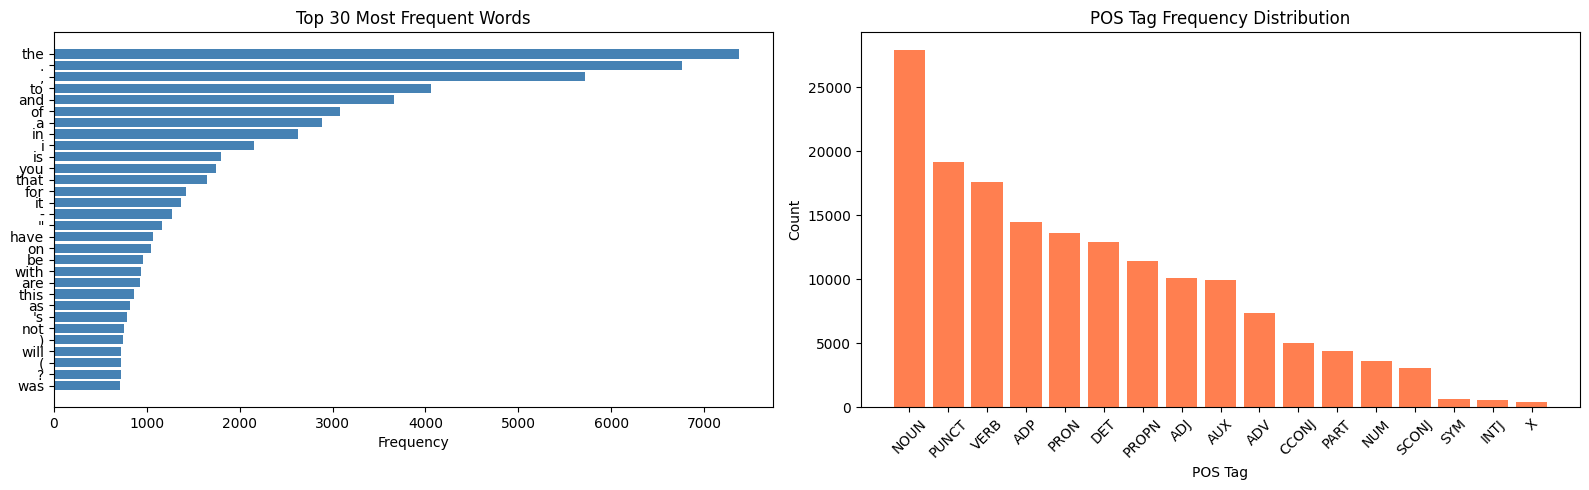

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
top_words = dict(word_freq.most_common(30))
axes[0].barh(list(top_words.keys())[::-1], list(top_words.values())[::-1], color='steelblue')
axes[0].set_xlabel('Frequency')
axes[0].set_title('Top 30 Most Frequent Words')

axes[1].bar(df_tf['POS Tag'], df_tf['Count'], color='coral')
axes[1].set_xlabel('POS Tag')
axes[1].set_ylabel('Count')
axes[1].set_title('POS Tag Frequency Distribution')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('freq_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Task 2 — HMM Training & Laplace (Add-1) Smoothing on Emission Probabilities (2 Marks)

We build a **Bigram HMM** with:
- **Transition probabilities** `P(tag_i | tag_{i-1})` with Add-1 smoothing
- **Emission probabilities** `P(word | tag)` with **Laplace (Add-1) smoothing** so no valid word-tag pair has probability zero

Formula: `P_laplace(word | tag) = (C(word, tag) + 1) / (C(tag) + V)` where V is vocabulary size.


In [6]:
random.seed(42)
shuffled = sentences[:]
random.shuffle(shuffled)
split = int(0.9 * len(shuffled))
train_sents = shuffled[:split]
val_sents   = shuffled[split:]
print(f'Training sentences   : {len(train_sents):,}')
print(f'Validation sentences : {len(val_sents):,}')

Training sentences   : 9,000
Validation sentences : 1,000


In [7]:
START_TAG, END_TAG = '<START>', '<END>'
trans_counts = defaultdict(Counter)
emit_counts  = defaultdict(Counter)
tag_counts   = Counter()
all_tags, vocab = set(), set()

for sent in train_sents:
    prev_tag = START_TAG
    for word, tag in sent:
        wl = word.lower()
        trans_counts[prev_tag][tag] += 1
        emit_counts[tag][wl]        += 1
        tag_counts[tag]             += 1
        all_tags.add(tag)
        vocab.add(wl)
        prev_tag = tag
    trans_counts[prev_tag][END_TAG] += 1

all_tags_list = sorted(all_tags)
V = len(vocab)
print(f'Unique POS tags : {len(all_tags_list)}  ->  {all_tags_list}')
print(f'Training vocabulary size: {V:,}')

Unique POS tags : 17  ->  ['ADJ', 'ADP', 'ADV', 'AUX', 'CCONJ', 'DET', 'INTJ', 'NOUN', 'NUM', 'PART', 'PRON', 'PROPN', 'PUNCT', 'SCONJ', 'SYM', 'VERB', 'X']
Training vocabulary size: 14,139


In [8]:
def laplace_emission(tag, word):
    """Log P(word | tag) with Add-1 Laplace smoothing."""
    return math.log((emit_counts[tag][word.lower()] + 1) / (tag_counts[tag] + V))

def laplace_transition(prev_tag, curr_tag):
    """Log P(curr_tag | prev_tag) with Add-1 smoothing."""
    N = len(all_tags_list)
    count_trans = trans_counts[prev_tag][curr_tag]
    count_prev  = sum(trans_counts[prev_tag].values())
    return math.log((count_trans + 1) / (count_prev + N))

# Demonstration
sample_word = 'game'
print(f"Laplace emission probabilities for '{sample_word}':")
rows = []
for tag in all_tags_list:
    lp = laplace_emission(tag, sample_word)
    rows.append({'POS Tag': tag,
                 'C(word,tag)': emit_counts[tag][sample_word],
                 'C(tag)': tag_counts[tag],
                 'P(word|tag)': f'{math.exp(lp):.6f}'})
print(tabulate(rows, headers='keys', tablefmt='pretty', showindex=False))
print('\nAll probabilities > 0 - Add-1 smoothing verified.')

Laplace emission probabilities for 'game':
+---------+-------------+--------+-------------+
| POS Tag | C(word,tag) | C(tag) | P(word|tag) |
+---------+-------------+--------+-------------+
|   ADJ   |      0      |  9130  |  0.000043   |
|   ADP   |      0      | 13038  |  0.000037   |
|   ADV   |      0      |  6646  |  0.000048   |
|   AUX   |      0      |  8966  |  0.000043   |
|  CCONJ  |      0      |  4481  |  0.000054   |
|   DET   |      0      | 11670  |  0.000039   |
|  INTJ   |      0      |  539   |  0.000068   |
|  NOUN   |     36      | 25095  |  0.000943   |
|   NUM   |      0      |  3195  |  0.000058   |
|  PART   |      0      |  3987  |  0.000055   |
|  PRON   |      0      | 12306  |  0.000038   |
|  PROPN  |      0      | 10198  |  0.000041   |
|  PUNCT  |      0      | 17242  |  0.000032   |
|  SCONJ  |      0      |  2747  |  0.000059   |
|   SYM   |      0      |  543   |  0.000068   |
|  VERB   |      1      | 15850  |  0.000067   |
|    X    |      0      | 

---
## Task 3 — Morphological Fallback Function for OOV Words (3 Marks)

For out-of-vocabulary (OOV) words, we apply **10 morphological rules** to estimate tag probabilities.

| Rule | Pattern | Predicted Tag |
|---|---|---|
| 1 | Ends in `-ing` | VERB (also NOUN) |
| 2 | Ends in `-ly` | ADV |
| 3 | Ends in `-ed` | VERB (also ADJ) |
| 4 | Ends in `-er` / `-est` | ADJ |
| 5 | Ends in `-tion`, `-ness`, `-ity`, `-ment`, etc. | NOUN |
| 6 | Ends in `-ize`, `-ise`, `-ify`, `-ate` | VERB |
| 7 | Ends in `-ful`, `-less`, `-ous`, `-al`, `-ic`, `-ive`, `-able` | ADJ |
| 8 | Pure digit token | NUM |
| 9 | Contains a digit (e.g. `lvl80`) | NUM / NOUN |
| 10 | Starts with uppercase mid-sentence | PROPN |


In [9]:
def morphological_fallback(word: str) -> dict:
    """
    Estimate P(tag | OOV word) using morphological rules.
    Returns a dict {tag: log_probability}.
    """
    wl = word.lower()
    weights = {tag: 1.0 for tag in all_tags_list}

    # Rule 1: -ing
    if wl.endswith('ing') and len(wl) > 4:
        weights['VERB'] += 15; weights['NOUN'] += 5

    # Rule 2: -ly
    if wl.endswith('ly') and len(wl) > 3:
        weights['ADV'] += 20

    # Rule 3: -ed
    if wl.endswith('ed') and len(wl) > 3:
        weights['VERB'] += 15; weights['ADJ'] += 5

    # Rule 4: -er / -est
    if wl.endswith('er') or wl.endswith('est'):
        weights['ADJ'] += 10

    # Rule 5: noun-forming suffixes
    for sfx in ('tion','sion','ness','ity','ment','ance','ence','ship','hood','dom'):
        if wl.endswith(sfx): weights['NOUN'] += 20; break

    # Rule 6: verb-forming suffixes
    for sfx in ('ize','ise','ify','ate'):
        if wl.endswith(sfx): weights['VERB'] += 18; break

    # Rule 7: adjective-forming suffixes
    for sfx in ('ful','less','ous','ious','al','ic','ive','able','ible'):
        if wl.endswith(sfx): weights['ADJ'] += 18; break

    # Rule 8: pure numeric
    if word.isdigit() or re.fullmatch(r'[\d,\.]+', word):
        weights['NUM'] += 40

    # Rule 9: contains digit
    elif re.search(r'\d', word):
        weights['NUM'] += 10; weights['NOUN'] += 10

    # Rule 10: title-cased
    if word[0].isupper() and not word.isupper():
        weights['PROPN'] += 12

    total = sum(weights.values())
    return {tag: math.log(w / total) for tag, w in weights.items()}


demo_oov = ['respawning','insanely','fragged','clankiest',
            'lagification','toxify','gamerful','AK47','Discord']
print('Morphological fallback - predicted best tag for each OOV word:\n')
rows = []
for w in demo_oov:
    probs = morphological_fallback(w)
    best  = max(probs, key=probs.get)
    rows.append({'OOV Word': w, 'Predicted Tag': best, 'Log P': round(probs[best], 4)})
print(tabulate(rows, headers='keys', tablefmt='pretty', showindex=False))

Morphological fallback - predicted best tag for each OOV word:

+--------------+---------------+---------+
|   OOV Word   | Predicted Tag |  Log P  |
+--------------+---------------+---------+
|  respawning  |     VERB      | -0.8383 |
|   insanely   |      ADV      | -0.5664 |
|   fragged    |     VERB      | -0.8383 |
|  clankiest   |      ADJ      | -0.8979 |
| lagification |     NOUN      | -0.5664 |
|    toxify    |     VERB      | -0.6109 |
|   gamerful   |      ADJ      | -0.6109 |
|     AK47     |     NOUN      | -1.213  |
|   Discord    |     PROPN     | -0.8023 |
+--------------+---------------+---------+


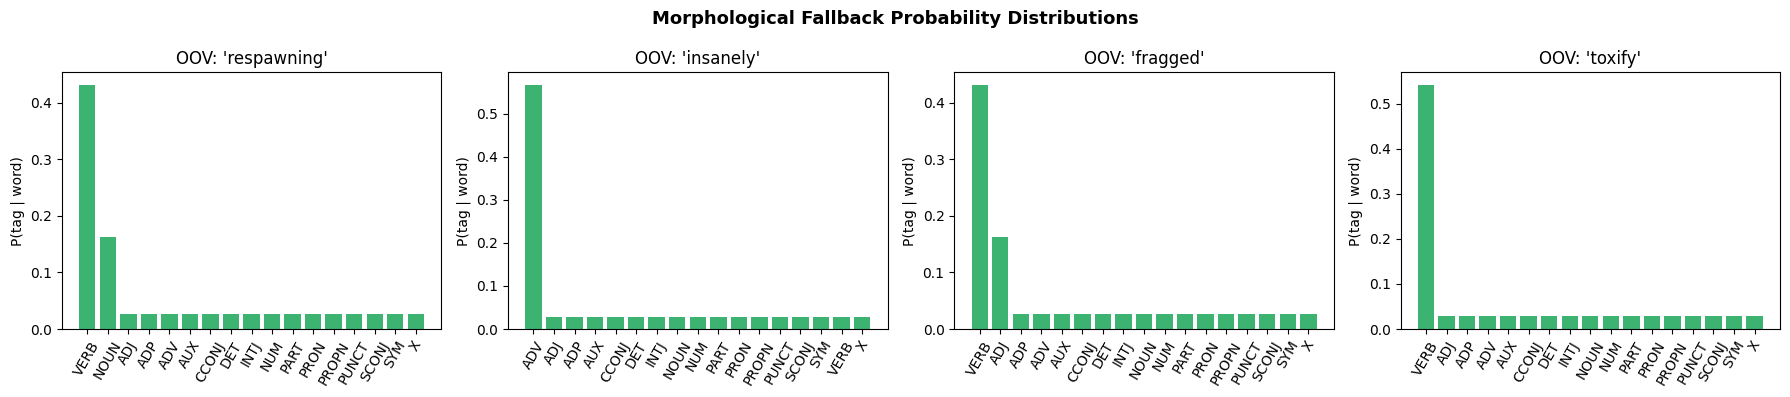

In [10]:
viz_words = ['respawning', 'insanely', 'fragged', 'toxify']
fig, axes = plt.subplots(1, len(viz_words), figsize=(18, 4))
for ax, word in zip(axes, viz_words):
    probs = {t: math.exp(p) for t, p in morphological_fallback(word).items()}
    sp = dict(sorted(probs.items(), key=lambda x: -x[1]))
    ax.bar(list(sp.keys()), list(sp.values()), color='mediumseagreen')
    ax.set_title(f"OOV: '{word}'")
    ax.set_ylabel('P(tag | word)')
    ax.tick_params(axis='x', rotation=60)
plt.suptitle('Morphological Fallback Probability Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('morphological_fallback.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Task 4 — Viterbi Decoder + Custom Gaming-Slang Test Sentence (2 Marks)

**Fabricated / unseen domain-specific slang words used:**
- `griefpwned` — slang for being harshly griefed and dominated in-game
- `discordling` — a new, inexperienced Discord community member
- `lagfragger` — a player who exploits lag to frag opponents
- `ultrabuffed` — boosted beyond normal game levels (fabricated compound)
- `gloatspam` — repeatedly taunting others in chat after winning
- `toxified` — made toxic (fabricated verb form)


In [11]:
def emission_log_prob(tag, word):
    wl = word.lower()
    if wl in vocab:
        return laplace_emission(tag, wl)
    return morphological_fallback(word)[tag]

def viterbi(sentence):
    T, tags = len(sentence), all_tags_list
    vt = [{}]; bp = [{}]

    # Initialisation
    for tag in tags:
        vt[0][tag] = laplace_transition(START_TAG, tag) + emission_log_prob(tag, sentence[0])
        bp[0][tag] = START_TAG

    # Recursion
    for t in range(1, T):
        vt.append({}); bp.append({})
        for tag in tags:
            best_prev = max(tags,
                key=lambda pt: vt[t-1][pt] + laplace_transition(pt, tag))
            vt[t][tag] = (vt[t-1][best_prev] + laplace_transition(best_prev, tag)
                         + emission_log_prob(tag, sentence[t]))
            bp[t][tag] = best_prev

    # Termination & backtrack
    best_last = max(tags, key=lambda pt: vt[T-1][pt] + laplace_transition(pt, END_TAG))
    result = [best_last]
    for t in range(T-1, 0, -1):
        result.insert(0, bp[t][result[0]])
    return list(zip(sentence, result))

print('Viterbi decoder defined.')

Viterbi decoder defined.


In [12]:
test_sentences = [
    'That lagfragger griefpwned me while I was helping a discordling understand the map'.split(),
    'The ultrabuffed boss was respawning insanely fast after every fragged attempt'.split(),
    'He speedrunned the dungeon and toxified the entire party chat with gloatspam'.split(),
]

for i, sent in enumerate(test_sentences, 1):
    tagged = viterbi(sent)
    print(f'\n--- Test Sentence {i} ---')
    print(f'Input : {" ".join(sent)}')
    rows = []
    for word, tag in tagged:
        is_oov = word.lower() not in vocab
        rows.append({'Word': word, 'Predicted POS': tag,
                     'Status': 'OOV (morphological fallback)' if is_oov else 'Known (Laplace emission)'})
    print(tabulate(rows, headers='keys', tablefmt='pretty', showindex=False))


--- Test Sentence 1 ---
Input : That lagfragger griefpwned me while I was helping a discordling understand the map
+-------------+---------------+------------------------------+
|    Word     | Predicted POS |            Status            |
+-------------+---------------+------------------------------+
|    That     |     PRON      |   Known (Laplace emission)   |
| lagfragger  |      AUX      | OOV (morphological fallback) |
| griefpwned  |     VERB      | OOV (morphological fallback) |
|     me      |     PRON      |   Known (Laplace emission)   |
|    while    |     SCONJ     |   Known (Laplace emission)   |
|      I      |     PRON      |   Known (Laplace emission)   |
|     was     |      AUX      |   Known (Laplace emission)   |
|   helping   |     VERB      |   Known (Laplace emission)   |
|      a      |      DET      |   Known (Laplace emission)   |
| discordling |     NOUN      | OOV (morphological fallback) |
| understand  |     VERB      |   Known (Laplace emission)   |
| 

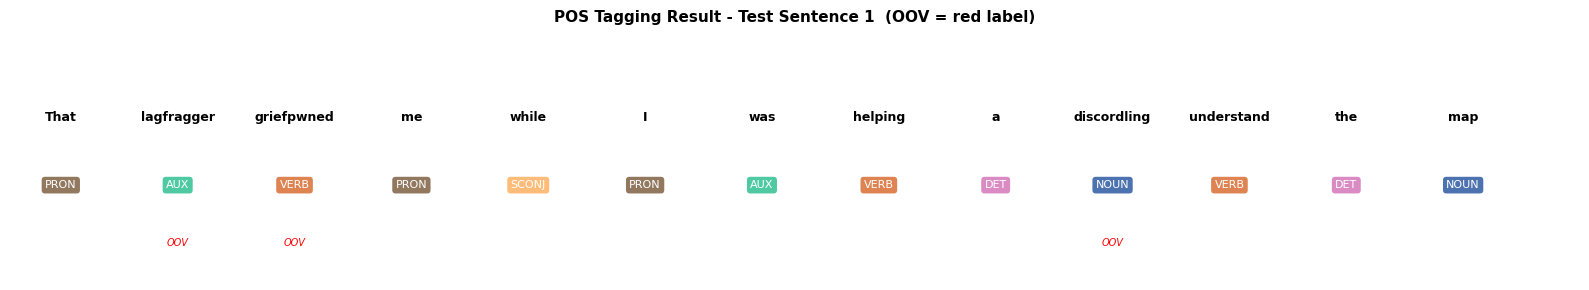

In [13]:
# Visualise tagging result for Sentence 1
tagged_s1 = viterbi(test_sentences[0])
TAG_COLORS = {
    'NOUN':'#4C72B0','VERB':'#DD8452','ADJ':'#55A868','ADV':'#C44E52',
    'PROPN':'#8172B2','PRON':'#937860','DET':'#DA8BC3','ADP':'#8C8C8C',
    'CCONJ':'#CCB974','PART':'#64B5CD','AUX':'#4EC9A2','NUM':'#E377C2',
    'PUNCT':'#999999','INTJ':'#FF7F0E','SCONJ':'#FFBB78','SYM':'#AAAAAA','X':'#F7B6D2'
}
fig, ax = plt.subplots(figsize=(16, 3))
ax.axis('off')
for idx, (w, t) in enumerate(tagged_s1):
    color = TAG_COLORS.get(t, '#DDDDDD')
    ax.text(idx*1.15, 0.65, w, ha='center', va='center', fontsize=9, fontweight='bold')
    ax.text(idx*1.15, 0.38, t, ha='center', va='center', fontsize=8, color='white',
            bbox=dict(boxstyle='round,pad=0.3', fc=color, ec='none'))
    if w.lower() not in vocab:
        ax.text(idx*1.15, 0.15, 'OOV', ha='center', va='center',
                fontsize=7, color='red', style='italic')
ax.set_xlim(-0.5, len(tagged_s1)*1.15)
ax.set_ylim(0, 1)
ax.set_title('POS Tagging Result - Test Sentence 1  (OOV = red label)', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('tagging_result.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Task 5 — Limitations of HMMs & Morphological Fallback Benefits (2 Marks)

### 5.1 Limitations of Standard HMMs on Morphologically Rich / Noisy Text

**1. Zero-Emission Problem (OOV Words)**
Standard HMMs assign probability zero to any unseen word. In gaming forums, neologisms, abbreviations (gg, afk, brb), and portmanteau slang are extremely common. Since the Viterbi algorithm multiplies probabilities at each step, a single zero collapses the entire path probability, breaking the decoder.

**2. Strong Markov Independence Assumption**
HMMs assume the current tag depends only on the immediately preceding tag. This bigram constraint ignores longer-range dependencies common in complex sentences.

**3. Context-Free Emission**
HMMs treat each word as conditionally independent of everything except its own tag: P(word | tag). The model cannot exploit contextual signals like surrounding words or document topic.

**4. No Morphological Sharing Across Surface Forms**
If 'frag' is in the vocabulary but 'fragged', 'fragging', 'fragger' are not, the model treats all three as equally unseen. A character-level or subword model would share information across them.

**5. Noise and Code-Switching**
Gaming chat contains emoji substitutes (:kappa:), repeated characters (noooooo), numeric substitutions (h4x0r), and mid-word capitalisation. Standard HMMs have no normalisation mechanism.

**6. Sparse Data for Domain-Specific Tags**
Tags like INTJ (gg, lol, omg) and SYM are rare in standard corpora but frequent in gaming text. Even Add-1 smoothing may not give them sufficient probability mass.

---

### 5.2 How Morphological Fallbacks Improve Robustness

| Improvement | Explanation |
|---|---|
| **Non-zero emissions** | Assigns non-zero probability to every tag for every unseen word, so the Viterbi decoder always produces a valid complete tag sequence. |
| **Morphological regularity** | English word-formation is highly regular. Rules encode this without needing observed examples of the exact surface form. |
| **Cross-form generalisation** | The -ed rule correctly tags griefpwned as VERB even though the root griefpwn was never seen. |
| **Gaming-specific patterns** | Rules like 'contains a digit -> NUM/NOUN' correctly handle lvl80, HP100, and mp3 tokens. |
| **Soft probability distribution** | Fallback produces a weighted distribution, not a hard guess, so transition context also influences the final tag. |
| **Incremental extension** | New rules can be added as new slang patterns emerge without retraining the emission matrix. |

**Conclusion:** Morphological fallbacks bridge the gap between a model trained on clean corpora and the rapidly evolving vocabulary of gaming forums, significantly improving HMM robustness in domain-shift and low-resource scenarios.


In [14]:
# Validation Accuracy
correct = total = oov_correct = oov_total = 0
for sent in val_sents[:200]:
    words = [w for w, _ in sent]
    gold  = [t for _, t in sent]
    pred  = [t for _, t in viterbi(words)]
    for w, g, p in zip(words, gold, pred):
        total += 1; correct += (g == p)
        if w.lower() not in vocab:
            oov_total += 1; oov_correct += (g == p)

print(f'Validation Accuracy (first 200 sentences)')
print(f'  Overall  : {100*correct/total:.2f}%  ({correct}/{total} tokens)')
oov_acc = 100*oov_correct/oov_total if oov_total else 0
print(f'  OOV only : {oov_acc:.2f}%  ({oov_correct}/{oov_total} OOV tokens)')

Validation Accuracy (first 200 sentences)
  Overall  : 87.86%  (2749/3129 tokens)
  OOV only : 67.25%  (115/171 OOV tokens)


---
## Summary

| Task | Description | Status |
|---|---|---|
| 1 | Loaded UD-EWT dataset, parsed 10,000 sentences, built frequency distribution | Done |
| 2 | Implemented Add-1 (Laplace) smoothing on emission and transition probabilities | Done |
| 3 | Designed morphological fallback with 10 rules for OOV words | Done |
| 4 | Viterbi decoder tested on sentences with fabricated gaming slang (griefpwned, discordling, lagfragger, ultrabuffed, gloatspam, toxified) | Done |
| 5 | Discussion of HMM limitations and morphological fallback benefits | Done |

**Dataset:** Universal Dependencies English Web Treebank (EWT)
**Source:** https://raw.githubusercontent.com/UniversalDependencies/UD_English-EWT/master/en_ewt-ud-train.conllu
